# Class 2 (Monday 14th October)

Experimenting with Numba
Let’s start by looking at the matvec code we wrote last week.

In [ ]:
import numpy as np

def slow_matvec(matrix, vector):
    assert matrix.shape[1] == vector.shape[0]
    result = []
    for r in range(matrix.shape[0]):
        value = 0
        for c in range(matrix.shape[1]):
            value += matrix[r, c] * vector[c]
        result.append(value)
    return np.array(result)


# Example of using this function
matrix = np.random.rand(3, 3)
vector = np.random.rand(3)
print(slow_matvec(matrix, vector))
print(matrix @ vector)

[0.41089804 0.62020587 0.80185285]
[0.41089804 0.62020587 0.80185285]


Use ``numba.njit`` to tell Numba to just-in-time (JIT) compile this function.

In [ ]:
import numpy as np
import numba

@numba.njit
def numba_matvec(matrix, vector):
    assert matrix.shape[1] == vector.shape[0]
    result = []
    dt = matrix.dtype
    for r in range(matrix.shape[0]):
        value = dt.type(0)
        for c in range(matrix.shape[1]):
            value += matrix[r, c] * vector[c]
        result.append(value)
    return np.array(result)


# Example of using this function
matrix = np.random.rand(10, 10)
vector = np.random.rand(10)
print(numba_matvec(matrix, vector))
print(matrix @ vector)

[1.63710133 1.85909651 2.13253893 2.01567435 1.33828263 2.66332314
 2.37501266 2.03915981 2.54839806 2.05753111]
[1.63710133 1.85909651 2.13253893 2.01567435 1.33828263 2.66332314
 2.37501266 2.03915981 2.54839806 2.05753111]


Why does this not give the correct value?

In [ ]:
numba_matvec.inspect_types(pretty=True)

/usr/local/lib/python3.10/dist-packages/numba/core/annotations/pretty_annotate.py:7: FutureWarning: The pretty_annotate functionality is experimental and might change API
  warn("The pretty_annotate functionality is experimental and might change API",


label 0
"matrix = arg(0, name=matrix) :: array(float64, 2d, C)"
"vector = arg(1, name=vector) :: array(float64, 1d, C)"
"5: def numba_matvec(matrix, vector):"
"$4load_attr.1 = getattr(value=matrix, attr=shape) :: UniTuple(int64 x 2)"
"$const6.2 = const(int, 1) :: Literal[int](1)"
"$8binary_subscr.3 = static_getitem(value=$4load_attr.1, index=1, index_var=$const6.2, fn=<built-in function getitem>) :: int64"
del $const6.2
del $4load_attr.1
"$12load_attr.5 = getattr(value=vector, attr=shape) :: UniTuple(int64 x 1)"
"$const14.6 = const(int, 0) :: Literal[int](0)"


Using matplotlib, make a plot that shows the time this function takes to compute a matrix-vector product with and without Numba acceleration.

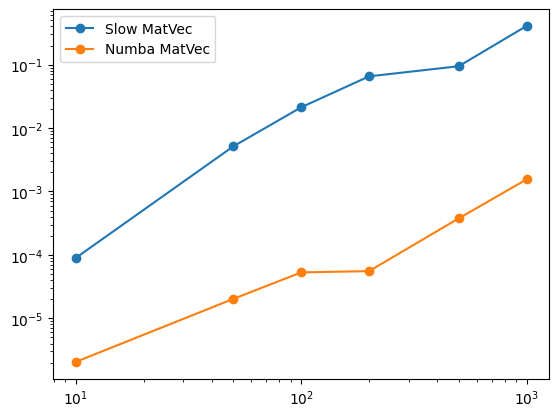

In [ ]:
import matplotlib.pyplot as plt

matrix_sizes = [10, 50, 100, 200, 500, 1000]

slow_matrix = []
numba_matrix = []

for s in matrix_sizes:
  mat = np.random.rand(s,s)
  vec = np.random.rand(s)

  t = %timeit -o -q -n1 -r3 slow_matvec(mat, vec)
  slow_matrix.append(t.average)
  t = %timeit -o -q -n100 -r6 numba_matvec(mat, vec)
  numba_matrix.append(t.average)


plt.figure()
plt.plot(matrix_sizes, slow_matrix, 'o-', label="Slow MatVec")
plt.plot(matrix_sizes, numba_matrix, 'o-', label="Numba MatVec")
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.show()


Add timings for the `faster_matvec` function that you wrote to this plot. The first time you call your function, it will need to do the JIT
compilation: you may want to measure the time the first run takes separately.

In [ ]:
def fast_matvec(matrix, vector):
    assert matrix.shape[1] == vector.shape[0]
    result = []
    for r in range(matrix.shape[0]):
        #value = 0
        value = matrix[r] @ vector #np.sum(matrix[r] * vector)
        # for c in range(matrix.shape[1]):
        #     value += matrix[r, c] * vector[c]
        result.append(value)
    return np.array(result)

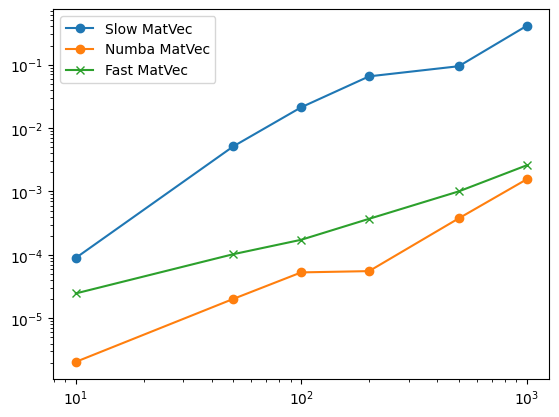

In [ ]:
import matplotlib.pyplot as plt

fast_matrix = []

for s in matrix_sizes:
  mat = np.random.rand(s,s)
  vec = np.random.rand(s)

  t = %timeit -o -q -n100 -r6 fast_matvec(mat, vec)
  fast_matrix.append(t.average)


plt.figure()
plt.plot(matrix_sizes, slow_matrix, 'o-', label="Slow MatVec")
plt.plot(matrix_sizes, numba_matrix, 'o-', label="Numba MatVec")
plt.plot(matrix_sizes, fast_matrix, 'x-', label="Fast MatVec")

plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.show()


## `jit` vs `njit`
Add another line to your plot to shw the timings if you use `numba.jit` instead of `numba.njit`. Which is faster?

In [ ]:
import numpy as np
import numba

@numba.jit(forceobj=True)
def numba_jit_matvec(matrix, vector):
    assert matrix.shape[1] == vector.shape[0]
    result = []
    dt = matrix.dtype
    for r in range(matrix.shape[0]):
        value = dt.type(0)
        for c in range(matrix.shape[1]):
            value += matrix[r, c] * vector[c]
        result.append(value)
    return np.array(result)


# Example of using this function
matrix = np.random.rand(10, 10)
vector = np.random.rand(10)
print(numba_jit_matvec(matrix, vector))
print(matrix @ vector)

[1.73236301 2.33931295 2.36471436 3.06862261 3.1050757  2.36223961
 2.79730439 3.171938   2.85735192 2.17448762]
[1.73236301 2.33931295 2.36471436 3.06862261 3.1050757  2.36223961
 2.79730439 3.171938   2.85735192 2.17448762]


In [ ]:
mat = np.random.rand(1000,1000)
vec = np.random.rand(1000)
%timeit numba_matvec(mat, vec) # njit version
%timeit numba_jit_matvec(mat, vec) # jit version

1.69 ms ± 71.3 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
1.82 ms ± 133 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


## Parallel range
Replace any `range`s in your function with `numba.prange`: this will make your function use a parallel for loop. Compare the timings of your function with and without
parellel ranges. How big does your matrix need to be before parallelisation becomes worth using?

In [ ]:
import multiprocessing

multiprocessing.cpu_count()

2

In [ ]:
import numpy as np
import numba

@numba.njit(parallel=True)
def numba_prange_matvec(matrix, vector):
    assert matrix.shape[1] == vector.shape[0]
    result = np.empty(shape=matrix.shape[0], dtype=matrix.dtype)
    dt = matrix.dtype
    for r in numba.prange(matrix.shape[0]):
        value = dt.type(0)
        for c in range(matrix.shape[1]):
            value += matrix[r, c] * vector[c]
        result[r] = value
    return result


# Example of using this function
matrix = np.random.rand(3, 3)
vector = np.random.rand(3)
print(numba_matvec(matrix, vector))
print(matrix @ vector)

[1.50738128 0.6059274  0.19267991]
[1.50738128 0.6059274  0.19267991]


In [ ]:
@numba.njit(parallel=True)
def invalid():
    z = []
    for i in numba.prange(10000):
        z.append(i)
    return np.array(z)

valie = invalid()

In [ ]:
valie

array([-70088184029043669,                  0,                  1, ...,
                     9996,               9997,               9998])

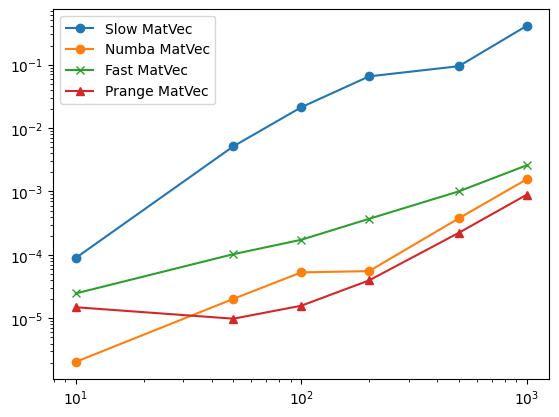

In [ ]:
import matplotlib.pyplot as plt

prange_matrix = []

for s in matrix_sizes:
  mat = np.random.rand(s,s)
  vec = np.random.rand(s)

  t = %timeit -o -q -n100 -r7 numba_prange_matvec(mat, vec)
  prange_matrix.append(t.average)


plt.figure()
plt.plot(matrix_sizes, slow_matrix, 'o-', label="Slow MatVec")
plt.plot(matrix_sizes, numba_matrix, 'o-', label="Numba MatVec")
plt.plot(matrix_sizes, fast_matrix, 'x-', label="Fast MatVec")
plt.plot(matrix_sizes, prange_matrix, '^-', label="Prange MatVec")


plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.show()



In [ ]:
mat = np.random.rand(1000,1000)
vec = np.random.rand(1000)

%timeit numba_matvec(mat, vec)
%timeit numba_prange_matvec(mat, vec) # prange version

1.64 ms ± 95.2 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
1.15 ms ± 483 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


## Optimising your code
Take the fastest version of your function you've obtained to far. Is there anything else you can try doing to it to make it faster? Try a few things and see if you can get any more speed.

In [ ]:
import numpy as np
import numba

@numba.njit(parallel=True,fastmath=True)
def numba_prange_opt_matvec(matrix, vector):
    assert matrix.shape[1] == vector.shape[0]
    result = np.empty(shape=matrix.shape[0], dtype=matrix.dtype)
    dt = matrix.dtype
    for r in numba.prange(matrix.shape[0]):
        value = dt.type(0)
        for c in range(matrix.shape[1]):
            value += matrix[r, c] * vector[c]
        result[r] = value
    return result


# Example of using this function
matrix = np.random.rand(3, 3)
vector = np.random.rand(3)
print(numba_prange_opt_matvec(matrix, vector))
print(matrix @ vector)

[2.04634019 0.75774054 1.57015626]
[2.04634019 0.75774054 1.57015626]


In [ ]:
print(list(numba_prange_opt_matvec.inspect_asm().values())[0])

	.text
	.file	"<string>"
	.globl	_ZN8__main__23numba_prange_opt_matvecB3v25B110c8tJTC_2fWQAliW1xhDEoY6EEMEUOEMISPGsAQMVj4QniQ4IXKQEMXwoMGLoQDDVsQR1NHAS2hQ9XgStYw86ABbYse0tXqICn1WqDBwFiD2AEAE5ArrayIdLi2E1C7mutable7alignedE5ArrayIdLi1E1C7mutable7alignedE
	.p2align	4, 0x90
	.type	_ZN8__main__23numba_prange_opt_matvecB3v25B110c8tJTC_2fWQAliW1xhDEoY6EEMEUOEMISPGsAQMVj4QniQ4IXKQEMXwoMGLoQDDVsQR1NHAS2hQ9XgStYw86ABbYse0tXqICn1WqDBwFiD2AEAE5ArrayIdLi2E1C7mutable7alignedE5ArrayIdLi1E1C7mutable7alignedE,@function
_ZN8__main__23numba_prange_opt_matvecB3v25B110c8tJTC_2fWQAliW1xhDEoY6EEMEUOEMISPGsAQMVj4QniQ4IXKQEMXwoMGLoQDDVsQR1NHAS2hQ9XgStYw86ABbYse0tXqICn1WqDBwFiD2AEAE5ArrayIdLi2E1C7mutable7alignedE5ArrayIdLi1E1C7mutable7alignedE:
	.cfi_startproc
	pushq	%rbp
	.cfi_def_cfa_offset 16
	pushq	%r15
	.cfi_def_cfa_offset 24
	pushq	%r14
	.cfi_def_cfa_offset 32
	pushq	%r13
	.cfi_def_cfa_offset 40
	pushq	%r12
	.cfi_def_cfa_offset 48
	pushq	%rbx
	.cfi_def_cfa_offset 56
	subq	$216, %rsp
	.cfi_def_cfa_offset 2

Compare the time your function takes to the time Numpy takes to multiply matrix vector. How close to Numpy's speed can you get?

In [ ]:
mat = np.random.rand(1000,1000)
vec = np.random.rand(1000)

%timeit numba_matvec(mat, vec)
%timeit numba_prange_matvec(mat, vec) # prange version
%timeit numba_prange_opt_matvec(mat, vec) # prange version

2.01 ms ± 422 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
1.13 ms ± 469 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
274 µs ± 15.2 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


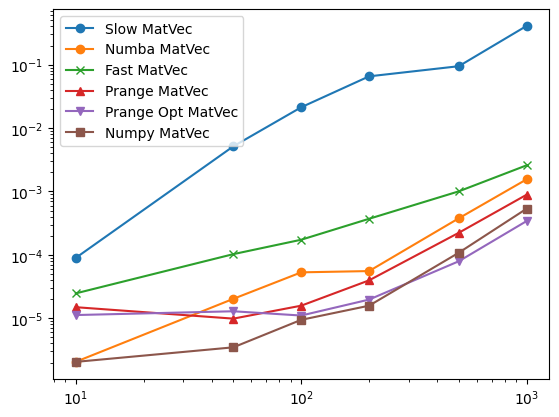

In [ ]:
import matplotlib.pyplot as plt

opt_matrix = []
numpy_matrix = []
for s in matrix_sizes:
  mat = np.random.rand(s,s)
  vec = np.random.rand(s)

  t = %timeit -o -q numba_prange_opt_matvec(mat, vec)
  opt_matrix.append(t.average)

  t = %timeit -o -q mat @ vec
  numpy_matrix.append(t.average)

plt.figure()
plt.plot(matrix_sizes, slow_matrix, 'o-', label="Slow MatVec")
plt.plot(matrix_sizes, numba_matrix, 'o-', label="Numba MatVec")
plt.plot(matrix_sizes, fast_matrix, 'x-', label="Fast MatVec")
plt.plot(matrix_sizes, prange_matrix, '^-', label="Prange MatVec")
plt.plot(matrix_sizes, opt_matrix, 'v-', label="Prange Opt MatVec")
plt.plot(matrix_sizes, numpy_matrix, 's-', label="Numpy MatVec")


plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.show()

